# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
import time
import os
import cv2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-11-29 18:41:11.750721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764441671.772073     236 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764441671.778686     236 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# CONFIGURATION AND HYPERPARAMETERS

In [2]:
# Dataset configuration
DATASET_PATH = '/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced for better gradient estimates
NUM_CLASSES = 16

# Training hyperparameters
EPOCHS = 100  # Increased, will use early stopping
INITIAL_LEARNING_RATE = 0.0001  # Lower initial LR
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

# ImageNet normalization values
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

# Class names mapping
CLASS_NAMES = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu',
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}



# DATA LOADING AND PREPROCESSING

In [3]:
def normalize_imagenet(images):
    """Apply ImageNet-style normalization"""
    normalized = np.zeros_like(images, dtype=np.float32)
    for i in range(3):
        normalized[:, :, :, i] = (images[:, :, :, i] - IMAGENET_MEAN[i]) / IMAGENET_STD[i]
    return normalized

def load_dataset(base_path):
    """Load images and labels from the dataset directory"""
    images = []
    labels = []
    class_counts = {}
    
    raw_images_path = os.path.join(base_path, 'Raw-Images')
    
    for class_idx, (type_folder, class_name) in enumerate(CLASS_NAMES.items()):
        folder_path = os.path.join(raw_images_path, type_folder)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found!")
            continue
            
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(image_files)
        
        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    print(f"\nDataset loaded successfully!")
    print(f"Total images: {len(images)}")
    print(f"\nClass distribution:")
    for class_name, count in class_counts.items():
        print(f"  {class_name:15s}: {count:4d} images")
    
    return np.array(images), np.array(labels), class_counts

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

X, y, class_counts = load_dataset(DATASET_PATH)

# Normalize to [0, 1] first
X = X.astype('float32') / 255.0


LOADING DATASET

Dataset loaded successfully!
Total images: 3494

Class distribution:
  Kalochitra     :  201 images
  Anantamu       :  158 images
  Apang          :  280 images
  Syspan         :  294 images
  Appishikha     :  138 images
  Kalamegh       :  294 images
  Kalothutura    :  276 images
  Gshnru         :  238 images
  Chapalish      :  238 images
  Beta           :  194 images
  Punarnava      :  407 images
  Bamonhati      :  134 images
  Basok          :  151 images
  Ramtulsi       :  154 images
  Shotomuli      :  108 images
  Sarpagandha    :  229 images


# DATA SPLITTING WITH SHUFFLING

In [4]:
print("\n" + "=" * 80)
print("SPLITTING DATASET")
print("=" * 80)

# Shuffle indices before splitting
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)

# Second split: separate train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), 
    random_state=SEED, stratify=y_temp
)

# Apply ImageNet normalization
print("Applying ImageNet-style normalization...")
X_train = normalize_imagenet(X_train)
X_val = normalize_imagenet(X_val)
X_test = normalize_imagenet(X_test)

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")


SPLITTING DATASET
Applying ImageNet-style normalization...
Training set: 2445 images
Validation set: 699 images
Test set: 350 images


#  DATA AUGMENTATION

In [5]:
print("\n" + "=" * 80)
print("CONFIGURING GENTLE LEAF-FRIENDLY AUGMENTATION")
print("=" * 80)

# augmentation for leaf images
train_datagen = ImageDataGenerator(
    rotation_range=10,           # Reduced from 20
    width_shift_range=0.08,      # Reduced from 0.2
    height_shift_range=0.08,    
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.08,             # Reduced from 0.15
    shear_range=0.0,             
    fill_mode='nearest'
)

# No augmentation for validation and test
val_test_datagen = ImageDataGenerator()

print("Gentle augmentation configured:")
print("  - Rotation: ±10 degrees ")
print("  - Width/Height shift: ±8% ")
print("  - Horizontal flip: Yes")
print("  - Zoom: ±8% ")
print("  ✓ Preserves leaf anatomical features!")
def se_block(input_tensor, reduction_ratio=16):
    """
    Squeeze-and-Excitation block for channel attention
    Helps model focus on important feature channels
    """
    channels = input_tensor.shape[-1]
    
    # Squeeze: Global average pooling
    se = layers.GlobalAveragePooling2D()(input_tensor)
    
    # Excitation: FC layers
    se = layers.Dense(channels // reduction_ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    
    # Reshape and scale
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([input_tensor, se])



CONFIGURING GENTLE LEAF-FRIENDLY AUGMENTATION
Gentle augmentation configured:
  - Rotation: ±10 degrees 
  - Width/Height shift: ±8% 
  - Horizontal flip: Yes
  - Zoom: ±8% 
  ✓ Preserves leaf anatomical features!


#  CUSTOM CNN MODEL ARCHITECTURE

In [6]:
def build_improved_custom_cnn(input_shape=(224, 224, 3), num_classes=16):
    """
    Build an improved custom CNN architecture:
    
    IMPROVEMENTS:
    1. NO L2 regularization (removed - too strong for small dataset)
    2. Lower dropout rates (0.1-0.3 instead of 0.25-0.5)
    3. Residual-like skip connections
    4. SE blocks for attention
    5. Flatten + larger Dense (preserves spatial features)
    6. Deeper architecture (5 blocks instead of 4)
    7. Correct layer ordering throughout
    """
    
    inputs = layers.Input(shape=input_shape)
    
    # Block 1: 32 filters
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)  # Reduced from 0.25
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 2: 64 filters with SE attention
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x, reduction_ratio=8)  # SE attention
    x = layers.Dropout(0.15)(x)  # Reduced
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 3: 128 filters with SE attention
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x, reduction_ratio=8)  # SE attention
    x = layers.Dropout(0.2)(x)  # Reduced
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 4: 256 filters with SE attention
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x, reduction_ratio=16)  # SE attention
    x = layers.Dropout(0.25)(x)  # Reduced
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 5: 512 filters with SE attention
    x = layers.Conv2D(512, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(512, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x, reduction_ratio=16)  # SE attention
    x = layers.Dropout(0.3)(x)  # Reduced
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Classification head - FLATTEN (not GAP) to preserve spatial features
    x = layers.Flatten()(x)
    
    # Larger dense layers to handle flattened features
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)  # Reduced from 0.5
    
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)  # Reduced from 0.5
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model

print("\n" + "=" * 80)
print("BUILDING IMPROVED CUSTOM CNN MODEL")
print("=" * 80)

model = build_improved_custom_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
    num_classes=NUM_CLASSES
)

# Compile model with lower initial learning rate
optimizer = Adam(learning_rate=INITIAL_LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


BUILDING IMPROVED CUSTOM CNN MODEL


I0000 00:00:1764441696.254599     236 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764441696.255199     236 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 224, 224,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p

 Total params: 17,751,352 (67.72 MB)

 Trainable params: 17,745,848 (67.70 MB)

 Non-trainable params: 5,504 (21.50 KB)


Total parameters: 17,751,352
Trainable parameters: 17,745,848


# CALLBACKS FOR TRAINING

In [7]:
print("\n" + "=" * 80)
print("CONFIGURING TRAINING CALLBACKS")
print("=" * 80)

# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

# Reduce learning rate on plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = callbacks.ModelCheckpoint(
    'best_custom_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callback_list = [early_stopping, reduce_lr, checkpoint]

print("Callbacks configured:")
print("  - Early Stopping: patience=10, monitor=val_loss")
print("  - Reduce LR on Plateau: factor=0.5, patience=5")
print("  - Model Checkpoint: saving best model based on val_accuracy")



CONFIGURING TRAINING CALLBACKS
Callbacks configured:
  - Early Stopping: patience=10, monitor=val_loss
  - Reduce LR on Plateau: factor=0.5, patience=5
  - Model Checkpoint: saving best model based on val_accuracy


# MODEL TRAINING

In [8]:
print("\n" + "=" * 80)
print("TRAINING IMPROVED CUSTOM CNN MODEL")
print("=" * 80)
print(f"Epochs: {EPOCHS} (with early stopping)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Initial learning rate: {INITIAL_LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Regularization: Dropout only (NO L2)")
print("=" * 80 + "\n")

# Record training start time
train_start_time = time.time()

# Train the model
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=1
)

# Record training end time
train_end_time = time.time()
training_time = train_end_time - train_start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")



TRAINING IMPROVED CUSTOM CNN MODEL
Epochs: 100 (with early stopping)
Batch size: 16
Initial learning rate: 0.0001
Optimizer: Adam
Regularization: Dropout only (NO L2)

Epoch 1/100


I0000 00:00:1764441706.762236     290 service.cc:148] XLA service 0x788898003f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764441706.762273     290 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764441706.762277     290 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764441708.076903     290 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/153 ━━━━━━━━━━━━━━━━━━━━ 1:09:35 27s/step - accuracy: 0.1250 - loss: 3.2117

I0000 00:00:1764441724.984204     290 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3605 - loss: 2.1021
Epoch 1: val_accuracy improved from -inf to 0.08441, saving model to best_custom_cnn_model.h5


...

153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - accuracy: 0.9669 - loss: 0.1279 - val_accuracy: 0.6052 - val_loss: 1.5441 - learning_rate: 1.0000e-04
Epoch 17/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9760 - loss: 0.1064
Epoch 17: val_accuracy did not improve from 0.60515
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9761 - loss: 0.1063 - val_accuracy: 0.3991 - val_loss: 2.1036 - learning_rate: 5.0000e-05
Epoch 18/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9803 - loss: 0.0730
Epoch 18: val_accuracy did not improve from 0.60515
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9803 - loss: 0.0730 - val_accuracy: 0.3548 - val_loss: 2.2660 - learning_rate: 5.0000e-05
Epoch 19/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9781 - loss: 0.0777
Epoch 19: val_accuracy did not improve from 0.60515
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9781 - loss: 0.0777 - val_accuracy: 0.5422 - val_loss: 1.6786 - learning

153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - accuracy: 0.9831 - loss: 0.0612 - val_accuracy: 0.6381 - val_loss: 1.1519 - learning_rate: 5.0000e-05
Epoch 22/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9819 - loss: 0.0709
Epoch 22: val_accuracy did not improve from 0.63805
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.9819 - loss: 0.0709 - val_accuracy: 0.6237 - val_loss: 1.2009 - learning_rate: 5.0000e-05
Epoch 23/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9816 - loss: 0.0693
Epoch 23: val_accuracy did not improve from 0.63805
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9816 - loss: 0.0693 - val_accuracy: 0.5980 - val_loss: 1.1913 - learning_rate: 5.0000e-05
Epoch 24/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9856 - loss: 0.0607
Epoch 24: val_accuracy improved from 0.63805 to 0.68240, saving model to best_custom_cnn_model.h5


153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.9856 - loss: 0.0607 - val_accuracy: 0.6824 - val_loss: 1.0035 - learning_rate: 5.0000e-05
Epoch 25/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9845 - loss: 0.0599
Epoch 25: val_accuracy did not improve from 0.68240
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9845 - loss: 0.0599 - val_accuracy: 0.6667 - val_loss: 1.0673 - learning_rate: 5.0000e-05
Epoch 26/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9835 - loss: 0.0653
Epoch 26: val_accuracy did not improve from 0.68240
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9835 - loss: 0.0653 - val_accuracy: 0.6009 - val_loss: 1.2538 - learning_rate: 5.0000e-05
Epoch 27/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9893 - loss: 0.0492
Epoch 27: val_accuracy did not improve from 0.68240
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.9893 - loss: 0.0492 - val_accuracy: 0.6624 - val_loss: 1.1141 - learning

153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 169ms/step - accuracy: 0.9914 - loss: 0.0366 - val_accuracy: 0.7010 - val_loss: 0.9893 - learning_rate: 2.5000e-05
Epoch 32/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9960 - loss: 0.0269
Epoch 32: val_accuracy did not improve from 0.70100
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.9960 - loss: 0.0269 - val_accuracy: 0.6280 - val_loss: 1.3565 - learning_rate: 2.5000e-05
Epoch 33/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9933 - loss: 0.0353
Epoch 33: val_accuracy did not improve from 0.70100
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 164ms/step - accuracy: 0.9933 - loss: 0.0353 - val_accuracy: 0.5494 - val_loss: 1.6420 - learning_rate: 2.5000e-05
Epoch 34/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9963 - loss: 0.0259
Epoch 34: val_accuracy did not improve from 0.70100
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.9962 - loss: 0.0260 - val_accuracy: 0.5551 - val_loss: 1.6517 - learning

153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.9957 - loss: 0.0241 - val_accuracy: 0.7239 - val_loss: 0.9469 - learning_rate: 1.2500e-05
Epoch 41/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9949 - loss: 0.0244
Epoch 41: val_accuracy did not improve from 0.72389
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.9949 - loss: 0.0244 - val_accuracy: 0.6567 - val_loss: 1.2012 - learning_rate: 1.2500e-05
Epoch 42/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9946 - loss: 0.0251
Epoch 42: val_accuracy did not improve from 0.72389
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.9946 - loss: 0.0251 - val_accuracy: 0.5808 - val_loss: 1.4469 - learning_rate: 1.2500e-05
Epoch 43/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9943 - loss: 0.0256
Epoch 43: val_accuracy did not improve from 0.72389
153/153 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9943 - loss: 0.0256 - val_accuracy: 0.6767 - val_loss: 1.1034 - learning

#  TRAINING HISTORY VISUALIZATION


VISUALIZING TRAINING HISTORY


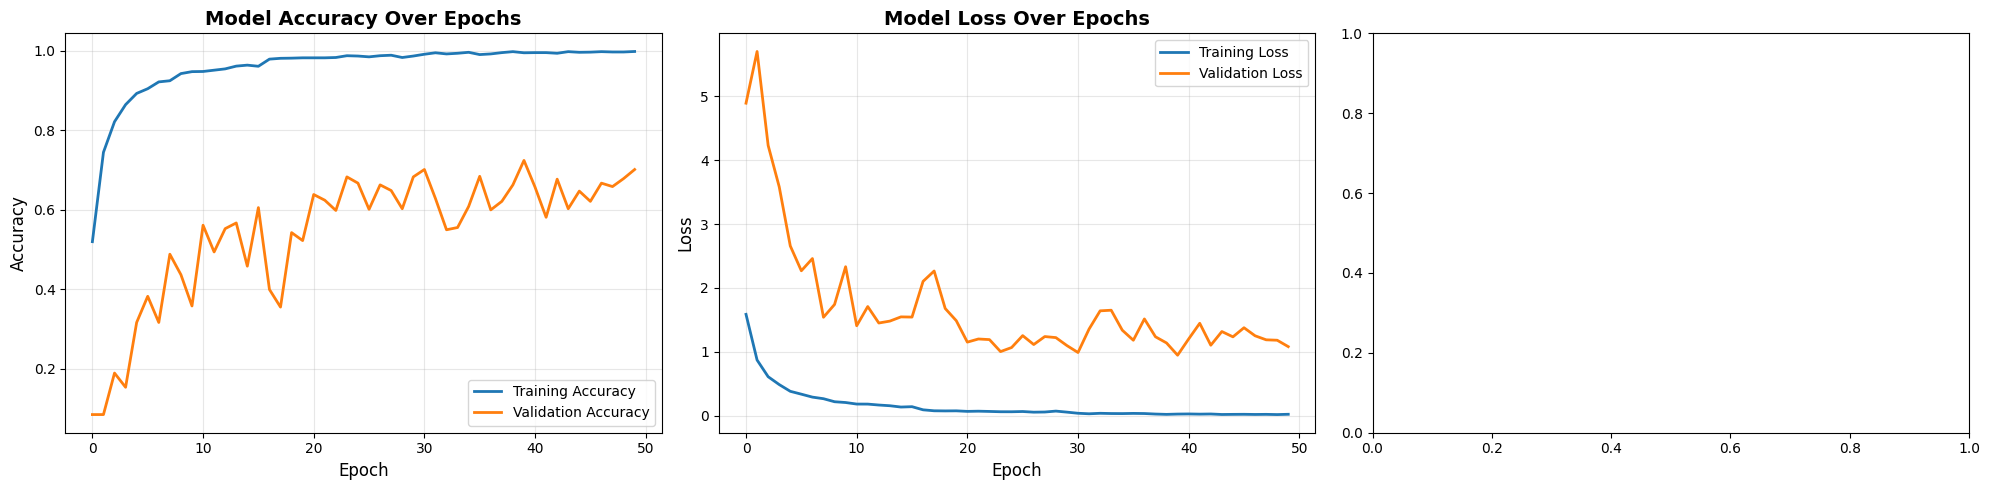


Final Training Accuracy: 0.9980 (99.80%)
Final Validation Accuracy: 0.7010 (70.10%)
Final Training Loss: 0.0215
Final Validation Loss: 1.0811

⚠ Overfitting detected: gap = 0.2970


In [9]:
print("\n" + "=" * 80)
print("VISUALIZING TRAINING HISTORY")
print("=" * 80)

def plot_training_history(history):
    """Plot training and validation accuracy/loss with learning rate"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Learning rate plot
    if 'lr' in history.history:
        axes[2].plot(history.history['lr'], linewidth=2, color='green')
        axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Epoch', fontsize=12)
        axes[2].set_ylabel('Learning Rate', fontsize=12)
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('custom_cnn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    print(f"\nFinal Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
    print(f"Final Training Loss: {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")
    
    # Check for overfitting/underfitting
    train_val_gap = final_train_acc - final_val_acc
    if train_val_gap > 0.15:
        print(f"\n⚠ Overfitting detected: gap = {train_val_gap:.4f}")
    elif final_train_acc < 0.7:
        print(f"\n⚠ Underfitting detected: train_acc = {final_train_acc:.4f}")
    else:
        print(f"\n✓ Good fit: gap = {train_val_gap:.4f}")

plot_training_history(history)

# MODEL EVALUATION ON TEST SET

In [10]:
print("\n" + "=" * 80)
print("EVALUATING MODEL ON TEST SET")
print("=" * 80)

# Record testing start time
test_start_time = time.time()

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Record testing end time
test_end_time = time.time()
testing_time = test_end_time - test_start_time

print(f"\nTesting completed in {testing_time:.2f} seconds")
print(f"Average prediction time per image: {testing_time/len(X_test)*1000:.2f} ms")



EVALUATING MODEL ON TEST SET
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 737ms/step

Testing completed in 9.26 seconds
Average prediction time per image: 26.46 ms


# PERFORMANCE METRICS

In [11]:
print("\n" + "=" * 80)
print("COMPUTING PERFORMANCE METRICS")
print("=" * 80)

# Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

# Create detailed classification report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

class_names_list = [CLASS_NAMES[f'type_{i+1}'] for i in range(NUM_CLASSES)]
report = classification_report(y_test, y_pred, target_names=class_names_list, 
                               digits=4, zero_division=0)
print(report)

# Per-class accuracy
print("\n" + "=" * 80)
print("PER-CLASS ACCURACY")
print("=" * 80)

class_accuracy = []
for i in range(NUM_CLASSES):
    mask = (y_test == i)
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == y_test[mask]).sum() / mask.sum()
        class_accuracy.append(class_acc)
        print(f"{class_names_list[i]:15s}: {class_acc:.4f} ({class_acc*100:.2f}%) [{mask.sum()} samples]")
    else:
        class_accuracy.append(0.0)
        print(f"{class_names_list[i]:15s}: N/A (no samples)")



COMPUTING PERFORMANCE METRICS

Test Accuracy: 0.7029 (70.29%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Kalochitra     1.0000    0.1000    0.1818        20
    Anantamu     1.0000    1.0000    1.0000        16
       Apang     1.0000    1.0000    1.0000        28
      Syspan     1.0000    0.0667    0.1250        30
  Appishikha     1.0000    0.5000    0.6667        14
    Kalamegh     0.2500    1.0000    0.4000        29
 Kalothutura     0.9655    1.0000    0.9825        28
      Gshnru     0.6053    0.9583    0.7419        24
   Chapalish     1.0000    0.9583    0.9787        24
        Beta     0.0000    0.0000    0.0000        19
   Punarnava     1.0000    0.9756    0.9877        41
   Bamonhati     1.0000    0.6154    0.7619        13
       Basok     1.0000    0.6667    0.8000        15
    Ramtulsi     1.0000    0.2000    0.3333        15
   Shotomuli     1.0000    0.9091    0.9524        11
 Sarpagandha     0.9444    0.7391    0.8293      

# CONFUSION MATRIX


CONFUSION MATRIX


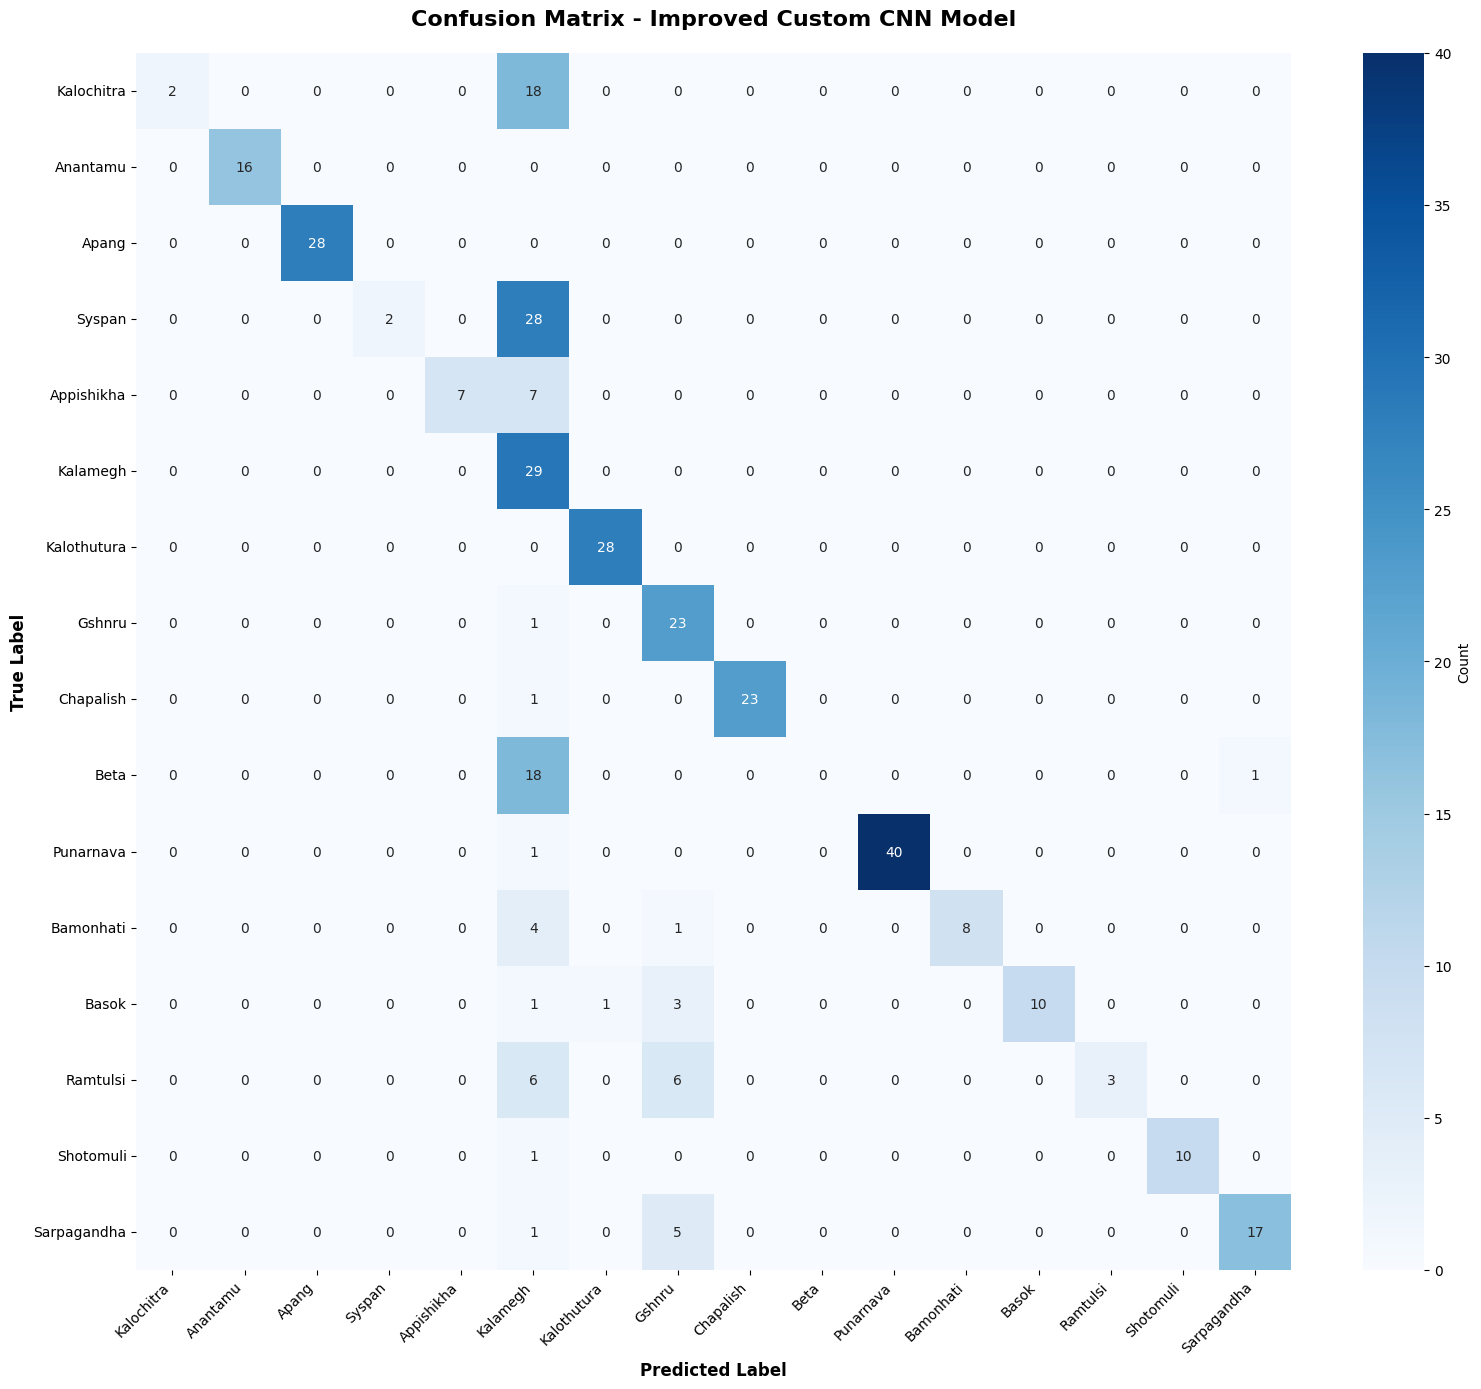

In [12]:
print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Improved Custom CNN Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('custom_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC CURVE AND AUC


ROC CURVE AND AUC COMPUTATION

Micro-average AUC: 0.9652
Macro-average AUC: 0.9972

Per-class AUC:
Kalochitra     : 1.0000
Anantamu       : 1.0000
Apang          : 1.0000
Syspan         : 1.0000
Appishikha     : 0.9983
Kalamegh       : 0.9992
Kalothutura    : 1.0000
Gshnru         : 0.9977
Chapalish      : 1.0000
Beta           : 0.9650
Punarnava      : 1.0000
Bamonhati      : 1.0000
Basok          : 0.9998
Ramtulsi       : 0.9958
Shotomuli      : 1.0000
Sarpagandha    : 0.9991


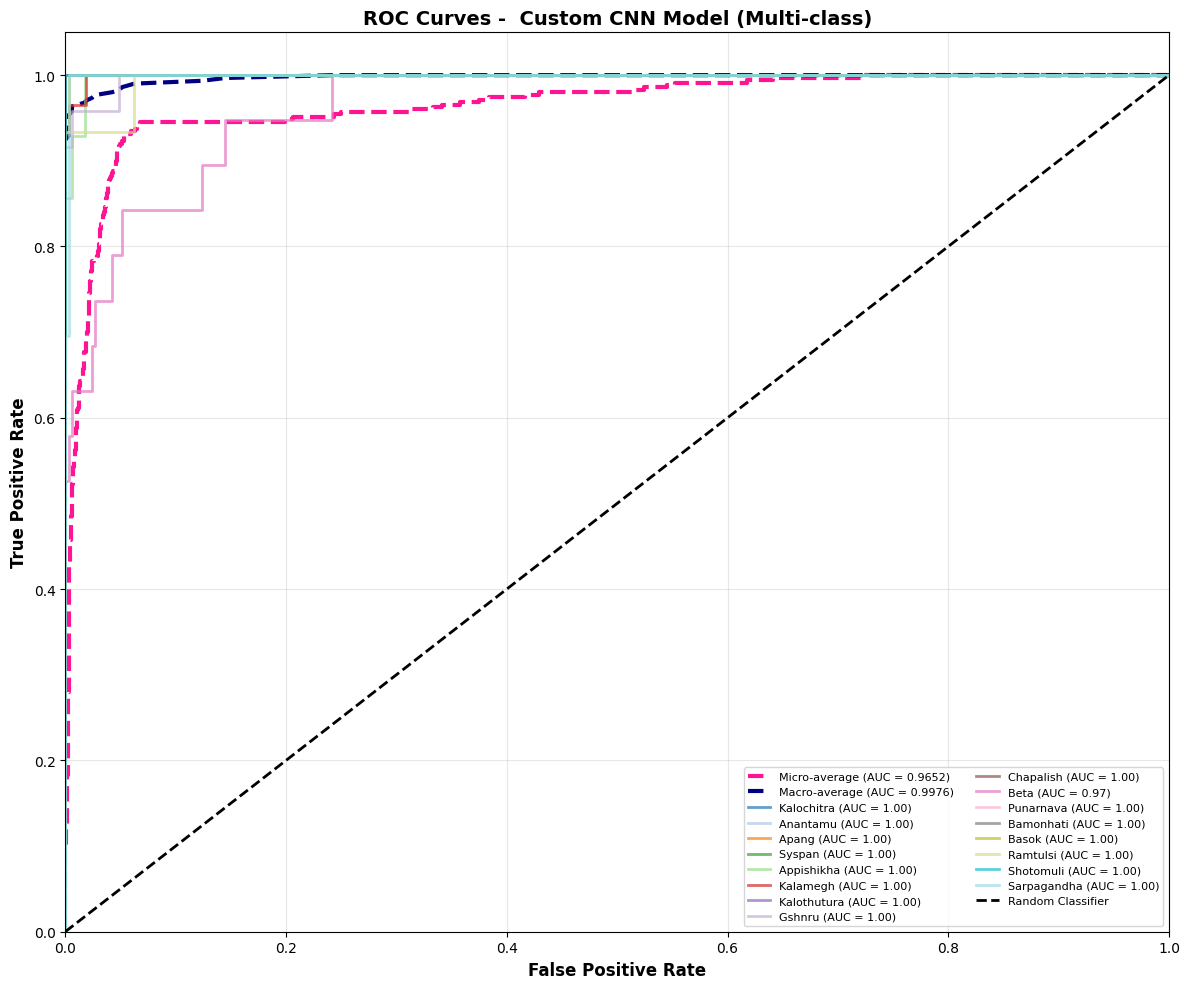

In [16]:
print("\n" + "=" * 80)
print("ROC CURVE AND AUC COMPUTATION")
print("=" * 80)

# Binarize labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), 
                                           y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average AUC
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])

print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {roc_auc['macro']:.4f}")

print("\nPer-class AUC:")
for i in range(NUM_CLASSES):
    print(f"{class_names_list[i]:15s}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle='--', linewidth=3)

# Plot macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linestyle='--', linewidth=3)

# Plot individual class ROC curves
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.7,
             label=f'{class_names_list[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves -  Custom CNN Model (Multi-class)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('custom_cnn_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# Summary Metrics Table

In [17]:
print("\n" + "=" * 80)
print("SUMMARY METRICS TABLE")
print("=" * 80)

# Create summary dataframe
summary_data = {
    'Class': class_names_list,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'Accuracy': class_accuracy,
    'AUC': [roc_auc[i] for i in range(NUM_CLASSES)]
}

summary_df = pd.DataFrame(summary_data)

# Add overall metrics
overall_metrics = pd.DataFrame({
    'Class': ['Overall (Macro Avg)', 'Overall (Weighted Avg)'],
    'Precision': [precision.mean(), 
                  np.average(precision, weights=support)],
    'Recall': [recall.mean(), 
               np.average(recall, weights=support)],
    'F1-Score': [f1.mean(), 
                 np.average(f1, weights=support)],
    'Support': [support.sum(), support.sum()],
    'Accuracy': [test_accuracy, test_accuracy],
    'AUC': [roc_auc['macro'], roc_auc['micro']]
})

summary_df = pd.concat([summary_df, overall_metrics], ignore_index=True)

print(summary_df.to_string(index=False))

# Save to CSV
summary_df


SUMMARY METRICS TABLE
                 Class  Precision   Recall  F1-Score  Support  Accuracy      AUC
            Kalochitra   1.000000 0.100000  0.181818       20  0.100000 1.000000
              Anantamu   1.000000 1.000000  1.000000       16  1.000000 1.000000
                 Apang   1.000000 1.000000  1.000000       28  1.000000 1.000000
                Syspan   1.000000 0.066667  0.125000       30  0.066667 1.000000
            Appishikha   1.000000 0.500000  0.666667       14  0.500000 0.998299
              Kalamegh   0.250000 1.000000  0.400000       29  1.000000 0.999248
           Kalothutura   0.965517 1.000000  0.982456       28  1.000000 1.000000
                Gshnru   0.605263 0.958333  0.741935       24  0.958333 0.997699
             Chapalish   1.000000 0.958333  0.978723       24  0.958333 1.000000
                  Beta   0.000000 0.000000  0.000000       19  0.000000 0.965018
             Punarnava   1.000000 0.975610  0.987654       41  0.975610 1.000000
     

,Class,Precision,Recall,F1-Score,Support,Accuracy,AUC
0,Kalochitra,1.000000,0.100000,0.181818,20,0.100000,1.000000
1,Anantamu,1.000000,1.000000,1.000000,16,1.000000,1.000000
2,Apang,1.000000,1.000000,1.000000,28,1.000000,1.000000
3,Syspan,1.000000,0.066667,0.125000,30,0.066667,1.000000
4,Appishikha,1.000000,0.500000,0.666667,14,0.500000,0.998299
5,Kalamegh,0.250000,1.000000,0.400000,29,1.000000,0.999248
6,Kalothutura,0.965517,1.000000,0.982456,28,1.000000,1.000000
7,Gshnru,0.605263,0.958333,0.741935,24,0.958333,0.997699
8,Chapalish,1.000000,0.958333,0.978723,24,0.958333,1.000000
9,Beta,0.000000,0.000000,0.000000,19,0.000000,0.965018
